# MATH 5010 — Python Computer Lab: Point Estimation-Simulation

This lab reinforces **Point Estimation 1–2** (method of moments, maximum likelihood, Bayes estimators, and evaluating estimators: bias, variance, MSE, Cramér–Rao lower bound(CRLB), sufficiency/Rao–Blackwell).

**What you'll learn**
1. Implement and compare estimators (MoM vs. MLE) for several models.
2. Explore bias/variance/MSE via simulation and verify the bias–variance decomposition.
3. Verify Cramér–Rao lower bound(CRLB) numerically on Poisson and Normal cases.
4. Perform a simple Beta–Binomial Bayesian update and compare frequentist/Bayes risks.
5. Apply Rao–Blackwellization on a Bernoulli problem.

_Use pure NumPy/SciPy and matplotlib (no seaborn). When plotting, keep one figure per cell._

In [1]:
# Setup (import libraries)
import numpy as np
import math
from math import sqrt, log
import scipy.stats as st
import matplotlib.pyplot as plt

Define three essential metrics for estimator evaluation — MSE, bias, and variance

In [2]:
rng = np.random.default_rng(2025)
# using the default_rng from NumPy’s newer random API for reproducibility.

def mse(x, theta_true):
    x = np.asarray(x)
    return np.mean((x - theta_true)**2)
#Compute mean squared error of estimator values.

def bias(estimates, theta_true):
    return np.mean(estimates) - theta_true
#Compute bias.
# if estimates is not array, you need add the following line:
# estimates = np.asarray(estimates)

def var(estimates):
    return np.var(estimates, ddof=0)


ddof=0 stands for "delta degrees of freedom" and, in statistical calculations like standard deviation, results in dividing the sum of squares by $N$ (the number of elements) instead of $N-1$.


**Study this example and complet the others distributions.**

## 1) Normal $(\mu,\sigma^2)$: MoM vs. MLE

Simulate i.i.d. data from a Normal distribution and estimate $(\mu,\sigma^2)$ using:
- Method of Moments (MoM): $\widehat\mu_{\text{MoM}}=\bar X$, $\widehat\sigma^2_{\text{MoM}}=\frac{1}{n}\sum (X_i-\bar X)^2$ (matches 2nd raw-moment solution)
- Maximum Likelihood (MLE): same formulas here for Normal; compare sampling distributions of the estimators.

We simulate R=5000 times.

In [3]:
# Normal: compare estimators for mu and sigma^2
mu_true, sigma_true, n = 2.0, 1.5, 50
R = 5000  # replications

mu_hat = np.empty(R)
sig2_hat_mom = np.empty(R)   # MoM == MLE here
sig2_hat_unbiased = np.empty(R)  # (n/(n-1)) * MoM to be unbiased

for r in range(R):
    x = rng.normal(mu_true, sigma_true, size=n)
    xbar = np.mean(x)
    s2_mle = np.mean((x - xbar)**2)      # divides by n
    s2_unb = np.var(x, ddof=1)           # divides by n-1

    mu_hat[r] = xbar
    sig2_hat_mom[r] = s2_mle
    sig2_hat_unbiased[r] = s2_unb

print("mu  : bias, var, mse ->", bias(mu_hat, mu_true), var(mu_hat), mse(mu_hat, mu_true))
print("s2_MLE (divide by n): bias, var, mse ->", bias(sig2_hat_mom, sigma_true**2), var(sig2_hat_mom), mse(sig2_hat_mom, sigma_true**2))
print("s2_unbiased         : bias, var, mse ->", bias(sig2_hat_unbiased, sigma_true**2), var(sig2_hat_unbiased), mse(sig2_hat_unbiased, sigma_true**2))


mu  : bias, var, mse -> -0.0023882456936865637 0.04597573754553689 0.04598144126303031
s2_MLE (divide by n): bias, var, mse -> -0.046972992532213986 0.19721208403429555 0.19941854606172696
s2_unbiased         : bias, var, mse -> -0.0020132576859324125 0.20534369432975383 0.20534774753626375


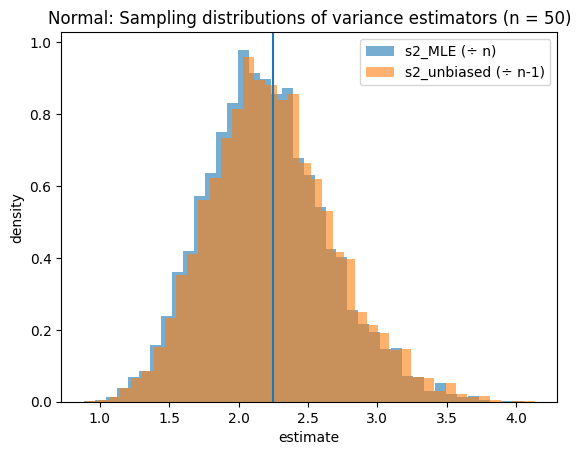

In [4]:
# Plot sampling distributions (histograms) for sigma^2 estimators
plt.figure()
plt.hist(sig2_hat_mom, bins=40, density=True, alpha=0.6, label='s2_MLE (÷ n)')
plt.hist(sig2_hat_unbiased, bins=40, density=True, alpha=0.6, label='s2_unbiased (÷ n-1)')
plt.axvline(sigma_true**2)
plt.legend()
plt.title("Normal: Sampling distributions of variance estimators (n = %d)" % n)
plt.xlabel("estimate")
plt.ylabel("density")
plt.show()


## 2) Uniform$(0,\theta)$: MLE and invariance
For $X_i\sim \text{Unif}(0,\theta)$, the MLE is $\widehat\theta_{\text{MLE}}=\max X_i$. Explore bias/MSE and the invariant MLE for $g(\theta)=\log\theta$.

In [5]:
# Uniform(0, theta): MLE properties
theta_true, n, R = 5.0, 30, 20000
theta_hat = np.empty(R)

for r in range(R):
    x = rng.uniform(0, theta_true, size=n)
    theta_hat[r] = np.max(x)

print("theta_MLE: bias, var, mse ->", bias(theta_hat, theta_true), var(theta_hat), mse(theta_hat, theta_true))

# Invariance: g(theta)=log theta
g_true = math.log(theta_true)
g_hat = np.log(theta_hat)  # invariant MLE
print("g(theta)=log theta: bias, var, mse ->", bias(g_hat, g_true), var(g_hat), mse(g_hat, g_true))


theta_MLE: bias, var, mse -> -0.1587198946152002 0.023872328405085824 0.04906433335174607
g(theta)=log theta: bias, var, mse -> -0.03279076122568991 0.0010883209862635056 0.00216355500802371


## 💻 <font color="blue" size="5" face="Georgia"> **Question 1** </font>

(1), print the bias, var, mse for both MLE and Bayes.

(2) draw similar historigram.

Hint: similar as in part (1)

## 3) Bernoulli/Binomial: MLE vs. Bayes (Beta prior)
Simulate Bernoulli$(p)$ with $p=0.35$. Compare the frequentist MLE $\hat p=\bar X$ to the Bayes estimator under **squared-error loss** with a Beta$(\alpha,\beta)$ prior:
$$\tilde p = \mathbb E[p\mid X_1,\dots,X_n] = \frac{\alpha + S}{\alpha+\beta + n},\quad S=\sum X_i.$$

In [6]:
# Bernoulli: MLE vs Bayes posterior mean
p_true, n, R = 0.35, 20, 20000
alpha, beta = n/4, n/4  # from slides: set to make Bayes MSE near-constant

p_mle = np.empty(R)
p_bayes = np.empty(R)

for r in range(R):
    x = rng.binomial(1, p_true, size=n)
    S = x.sum()
    p_mle[r] = S / n
    p_bayes[r] = (alpha + S) / (alpha + beta + n)

print("MLE  : bias, var, mse ->", bias(p_mle, p_true), var(p_mle), mse(p_mle, p_true))
print("Bayes: bias, var, mse ->", bias(p_bayes, p_true), var(p_bayes), mse(p_bayes, p_true))


MLE  : bias, var, mse -> -0.0008499999999999619 0.0113310275 0.011331750000000002
Bayes: bias, var, mse -> 0.04943333333333333 0.005036012222222223 0.007479666666666669


## 💻 <font color="blue" size="5" face="Georgia"> **Question 2** </font>
Your turn:

(1), print the bias, var, mse for both MLE and Bayes.

(2) draw similar historigram.



## 4) CRLB checks
**(a) Poisson mean)** For $X_i\sim \text{Pois}(\lambda)$, the CRLB for unbiased estimators of $\lambda$ is $\lambda/n$. Show $\operatorname{Var}(\bar X)$ matches it. (Study this example:)

In [7]:
# (a) Poisson CRLB check
lam_true, n, R = 4.0, 40, 40000
lam_hat = np.empty(R)
for r in range(R):
    x = rng.poisson(lam_true, size=n)
    lam_hat[r] = np.mean(x)

var_emp = var(lam_hat)
crlb = lam_true / n
print("Poisson: Var(xbar)≈", var_emp, "  CRLB=", crlb)


Poisson: Var(xbar)≈ 0.10001465357773438   CRLB= 0.1
Normal Var: Var(S^2)≈ 1.3355465082081415   2*sigma^4/(n-1)= 1.3333333333333333


## 💻 <font color="blue" size="5" face="Georgia"> **Question 3** </font>
Your turn:

**(b) Normal variance (unknown $\mu$)** Any unbiased estimator $W$ of $\sigma^2$ must satisfy $\operatorname{Var}(W)\ge 2\sigma^4/(n-1)$; compare with $\operatorname{Var}(S^2)=2\sigma^4/(n-1)$. Complete the following code.

In [ ]:
# (b) Normal variance case
mu_true, sigma_true, n, R = 0.0, 2.0, 25, 20000
S2 = np.empty(R)
for r in range(R):
    x = rng.normal(mu_true, sigma_true, size=n)
    S2[r] = np.var(x, ddof=1)

print("Normal Var: Var(S^2)≈", var(S2), "  2*sigma^4/(n-1)=", 2*sigma_true**4/(n-1))

# **Study the following:**

## 5) Rao–Blackwellization on a Bernoulli problem
Let $X_1,\dots,X_n\overset{iid}{\sim}\text{Bern}(p)$ and consider estimating $p^2$.

A naive unbiased estimator is $W=\frac{1}{n}\sum X_i^2=\bar X$ (since $X_i^2=X_i$ giving bias for $p^2$ actually).

Try instead $\widetilde W=\frac{S(S-1)}{n(n-1)}$, which satisfies $\mathbb E[\widetilde W]=p^2$ and is a function of the sufficient statistic $S=\sum X_i$.

Compare their MSEs and comment.

In [ ]:
# Rao–Blackwell: estimating p^2
p_true, n, R = 0.4, 30, 30000

W_naive = np.empty(R)      # uses Xbar as a plug-in for p^2 (biased)
W_RB = np.empty(R)         # unbiased U-statistic S(S-1)/(n(n-1))

for r in range(R):
    x = rng.binomial(1, p_true, size=n)
    S = x.sum()
    W_naive[r] = (S/n)**2
    W_RB[r] = (S*(S-1))/(n*(n-1))

print("Naive plug-in for p^2 : bias, var, mse ->", bias(W_naive, p_true**2), var(W_naive), mse(W_naive, p_true**2))
print("Rao–Blackwell (U-stat): bias, var, mse ->", bias(W_RB,   p_true**2), var(W_RB),   mse(W_RB,   p_true**2))


Naive plug-in for p^2 : bias, var, mse -> 0.008091074074074028 0.00531026188658299 0.005375727366255144
Rao–Blackwell (U-stat): bias, var, mse -> 8.950191570877841e-05 0.0052331959177111306 0.005233203928304046


## 6) Lognormal MLE via transformation
If $X\sim\text{Lognormal}(\mu,\sigma^2)$ then $Y=\log X\sim N(\mu,\sigma^2)$. Implement MLE for $(\mu,\sigma^2)$ by maximizing the Normal likelihood for $Y$.

In [ ]:
# Lognormal: MLE via log-transform
mu_true, sigma_true, n = 0.5, 0.6, 80
x = rng.lognormal(mean=mu_true, sigma=sigma_true, size=n)
y = np.log(x)

mu_hat = np.mean(y)
sig2_hat = np.mean((y - mu_hat)**2)  # divide by n (MLE)

print("True (mu, sigma^2)=", (mu_true, sigma_true**2))
print("MLE  (mu, sigma^2)≈", (mu_hat, sig2_hat))


True (mu, sigma^2)= (0.5, 0.36)
MLE  (mu, sigma^2)≈ (np.float64(0.37643745456252037), np.float64(0.33795096042236505))


## 7) Decision-theory flavor: choose $b$ to minimize risk for $\delta_b(X)=bS^2$ (Normal variance)
Simulate the risk (MSE) of $\delta_b$ and verify the optimal $b\approx\frac{n-1}{n+1}$ under squared-error loss as in the slides.

Empirically optimal b ≈ 0.875   Theoretical (n-1)/(n+1) = 0.9047619047619048


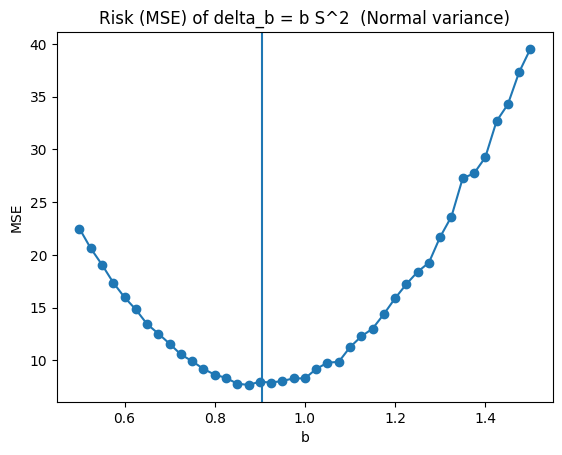

In [ ]:
# Risk over b for delta_b = b * S^2 (Normal with unknown mu)
mu_true, sigma_true, n, R = 1.0, 3.0, 20, 5000
b_grid = np.linspace(0.5, 1.5, 41)
mse_grid = []

for b in b_grid:
    ests = []
    for r in range(R):
        x = rng.normal(mu_true, sigma_true, size=n)
        s2 = np.var(x, ddof=1)
        ests.append(b * s2)
    mse_grid.append(mse(ests, sigma_true**2))

mse_grid = np.array(mse_grid)
b_star = b_grid[np.argmin(mse_grid)]
print("Empirically optimal b ≈", b_star, "  Theoretical (n-1)/(n+1) =", (n-1)/(n+1))

plt.figure()
plt.plot(b_grid, mse_grid, marker='o')
plt.axvline((n-1)/(n+1))
plt.title("Risk (MSE) of delta_b = b S^2  (Normal variance)")
plt.xlabel("b")
plt.ylabel("MSE")
plt.show()


### Wrap-up
- You compared MoM/MLE on Normal, inspected MLE invariance, and studied bias–variance tradeoffs.
- You checked CRLB numerically and saw how a RB/U-statistic improves performance for $p^2$.
- You implemented Beta–Binomial updating and explored decision-theoretic risk tuning for variance estimation.

**Optional extensions**: Try other priors, different $n$, or heavy-tailed models (Cauchy) to see how assumptions matter.